Principios de Machine Learning - (PML) Proyecto Tarea de Clasificacion: arboles de decision y K-vecinos mas cercanos

Diego Burbano



### Importar las librerias necesarias para el modelo

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from google.colab import drive

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, validation_curve
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from importlib.metadata import version

from mlxtend.plotting import heatmap

print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de Scikit-learn: {version('scikit-learn')}")
print(f"Versión de Numpy: {version('numpy')}")
print(f"Versión de mlxtend: {version('mlxtend')}")

Versión de Pandas: 2.2.2
Versión de Matplotlib: 3.10.0
Versión de Scikit-learn: 1.6.1
Versión de Numpy: 1.26.4
Versión de mlxtend: 0.23.4


##**1. Exploración y perfilamiento de los datos**

En esta sección se cargan al ambiente Colabs los datos alamcenados en la carpeta Drive de Google Drive

In [2]:
# En esta celda se esta montando el drive  que tiene almacenado los datos en la ruta MyDrive/datos.
drive.mount('/content/drive', force_remount=True)

# una vez se montó el drive, se cambia la ruta de archivo de 'content' de Colab por la ruta de Google Drive ('/MyDrive/datos/')
os.chdir('/content/drive/MyDrive/datos/')

Mounted at /content/drive


Se almacenan los datos en la variable *datos_crudos*:

In [3]:
datos_crudos = pd.read_csv('./Datos_Etapa-2.csv', sep=';', na_values=['?'], encoding = 'utf-8')


Se revisan los primeros datos del conjunto:

In [4]:
datos_crudos.head()

,pH,Dureza,Sólidos,Cloraminas,Sulfatos,Conductividad,Carbono_orgánico,Trihalometanos,Turbidez,Potabilidad
0,NaN,204.89,20791.32,7.30,368.52,564.31,10.38,86.99,2.96,NO
1,3.72,129.42,18630.06,6.64,NaN,592.89,15.18,56.33,4.50,NO
2,8.10,224.24,19909.54,9.28,NaN,418.61,16.87,66.42,3.06,NO
3,8.32,214.37,22018.42,8.06,356.89,363.27,18.44,100.34,4.63,NO
4,9.09,181.10,17978.99,6.55,310.14,398.41,11.56,32.00,4.08,NO


Nuestro conjunto trae una (1) variable categórica: *Potabilidad*. Las variables restantes son de tipo numérico.

In [5]:
datos_crudos.shape

(3276, 10)

###**Revisión de Variables Independientes**

Se exploran las variables independientes, que para nuestro caso corresponden a las variables numéricas:

In [6]:
variables_cat = ['Potabilidad']
variables_num = list(set(datos_crudos.columns) - set(variables_cat))

datos_crudos_cat = datos_crudos[variables_cat]
datos_crudos_num = datos_crudos[variables_num]

datos_crudos_num.describe()

,Sólidos,pH,Sulfatos,Turbidez,Conductividad,Trihalometanos,Dureza,Carbono_orgánico,Cloraminas
count,3276.000000,2785.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000,3276.000000
mean,22014.092415,7.080804,333.775784,3.966731,426.205171,66.396281,196.369481,14.284921,7.122241
std,8768.570852,1.594369,41.416864,0.780354,80.824123,16.174983,32.879680,3.308232,1.583143
min,320.940000,0.000000,129.000000,1.450000,181.480000,0.740000,47.430000,2.200000,0.350000
25%,15666.687500,6.090000,307.695000,3.440000,365.735000,55.847500,176.847500,12.070000,6.130000
50%,20927.830000,7.040000,333.070000,3.955000,421.885000,66.620000,196.965000,14.220000,7.130000
75%,27332.760000,8.060000,359.950000,4.500000,481.790000,77.337500,216.670000,16.560000,8.112500
max,61227.200000,14.000000,481.030000,6.740000,753.340000,124.000000,323.120000,28.300000,13.130000


En esta primera revisión de los datos numéricos encontramos las siguientes novedades confrontando los valores encontrados vs. la información contenida en el diccionario de datos:

1. *pH*: Encontramos que existen valores fuera del rango válido 6.5 a 8.5 y del rango de la investigación, ya que el mínimo muestra un valor de 0 y el valor máximo es de 14. Del total de datos del arreglo (3276) encontramos que el conteo de valores es de 2785, indicando una cantidad considerable de instancias sin valor en esta variable: 491.
2. *Trihalometanos*: Se encuentran 3114 valores de un total de 3276 de valores en el arreglo. Indicando 162 instancias sin valores en este campo.
3. *Sulfatos*: Se encuentran 2495 valores de un total de 3276 de valores en el arreglo. Indicando 781 instancias sin valores en este campo.

Con respecto a las otras variables encontramos:
- *Turbidez*: Variable numérica. No presenta ausencia de datos. De acuerdo con el diccionario de datos esta variable debería presentar una media de 0.98 NTU, sin embargo la media del set de datos es de 3.98 NTU, lo cual puede indicar errores en el set de datos o problemas de muestreo.
- *Carbón orgánico*: Variable numérica. No presenta ausencia de datos. El diccionario de datos no indica el rango válido de esta variable. Según la página fuente de los datos indica que el agua potable debe contener valores inferiores a 2mg / L y para ser tratada de 4mg /L. En nuestro describe encontramos el rango de 2.2 a 28.3 con una media de 14.2 mg/L, esto podría ser un indicio, ademas de los problemas de potabilidad del agua, de una distribución sesgada con outliers y/o problemas en la recolección de datos.
- *Sólidos*: Variable numérica. No presenta ausencia de datos. El diccionario de datos no indica el rango válido de esta variable. Según la página fuente de los datos indica que el agua potable debe contar con valores inferiorea a 500 mg/L y su valor máximo no debería superar 1000 mg/L. En la exploración inicial encontramos un rango entre 320 y 61.227 mg/L, con un valor medio de 22.014 mg/L, esto además de representar un indicio que los datos fueron obtenidos en su mayoria de fuentes no potables de agua, que puede haber problemas en la unidad de medida (g/L en lugar de mg/L), pero principalemente al tener un rango tan amplio de datos puede ser indicio de la existencia de valores atípicos.
- *Dureza*: Variable numérica. No presenta ausencia de datos. El diccionario de datos no indica el rango válido para esta variable. Según la página fuente de datos, no contamos tampoco con un rango que nos permita analizar posibles problemas en los valores de los datos. Revisando el rango de la variable entre 47.4 y 323.12 con una media de 196.3 y una desviación estándar de 32.8, podríamos concluir que la muestra se encuentra relativamente concentrada y considerando el valor de desviación de estándar se puede concluir que no existen valores extremos.
- *Conductividad*: Variable numérica. No presenta ausencia de datos. El diccionario no nos arroja un rango válido de datos y la página fuente nos indica que valores inferiores a 400 uS/cm son aptos para consumo humano. Considerando que la muestra tiene un rango entre 181.4 y 753.34 con una media de 426.2 y una desviación estándar de 80.8 uS/cm, esto, además de ser un indicio que los datos provienen principalmente de fuentes no aptas para el consumo, contamos con una muestra con dispersión moderada, por lo que podríamos tener una tendencia hacia valores elevados, con algunos casos particularmente extremos.
- *Cloraminas*: Variable numérica. No presenta ausencia de datos. El diccionario no ofrece un rango válido para los datos, no obstance nos dice que valores inferiores a 4 mg/L son seguros para el consumo humano. Evaluando el rango de los datos entre 0.35 y 13.1, con media de 7.12 y desviación estándar de 1.58 nos indica una distribución anómala, con presencia de valores extremos.

De esta primera etapa concluimos:
1. Set de datos desbalanceado con una tendencia clara hacia fuentes de agua no potables.
2. Importantes ausencias de datos en las variables: pH, Trihalometanos y Sulfatos, indicando problemas en la recolección de los datos, posibles problemas en los instrumentos de medición, entre otros.
3. Presencia de valores extremos en algunas de las variables tales como: carbón orgánico, sólidos, conductividad y cloraminas.
4. Distribución anómala de las variables, ya que  que algunas variables muestran distribuciones sesgadas (como la dureza y la conductividad), lo que podría indicar patrones subyacentes relacionados con fuentes específicas de agua.
5. Falta de información en el diccionario relacionada con el rango válido de las variables, lo cual es una fuerte limitación en el momento de evaluar posibles inconsistencias (valores fuera de rango).

Como complemento al análisis presentado, se verifica si existen datos repetidos la confirmación de la existencia de datos nulos:

In [7]:
datos_crudos_num.isna().sum()

,0
Sólidos,0
pH,491
Sulfatos,781
Turbidez,0
Conductividad,0
Trihalometanos,162
Dureza,0
Carbono_orgánico,0
Cloraminas,0


Comprobando de esta manera los resultados encontrados mediante la descripción inicial de los datos crudos obtenidos en el paso anterior. En la etapa de *Limpieza y Preparación*, alistaremos los datos realizando un proceso de imputación. Se toma la decisión de imputar considerando que el volumen de instancias identificadas con valores nulos representan un porcentaje importante del set de datos. Esto se realizará mas adelante en el paso *2. Limpieza y prepación.*

###**Análisis de correlación de variables independientes**

Se revisa la relación entre variables independientes para verificar posibles correlaciones. Para ello se prepara un set temporal (*datos_crudos_no_vacios*) solo para propósitos de construir el mapa de calor:

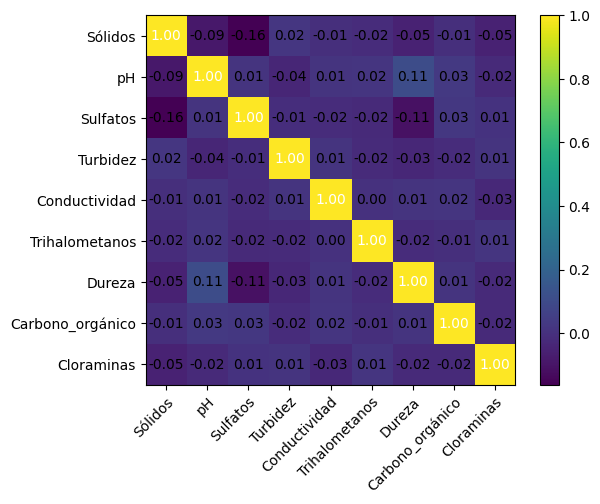

In [8]:
datos_crudos_no_vacios = datos_crudos.dropna()                        #Preparacion de set temporal para propositos de construir mapa de calor
cm = np.corrcoef(datos_crudos_no_vacios[variables_num].values.T)
hm = heatmap(cm,row_names=variables_num, column_names=variables_num)
plt.show()

Del mapa de calor se concluye que no existen correlaciones fuertes entre las variables independientes a tratar.

A continuación, se revisa si alguna de las variables independientes presenta baja varianza, como indicativo que esta variable pueda llegar a ser descartada:

In [9]:
varianza = datos_crudos_no_vacios[variables_num].var()

# Mostrar las variables con muy baja varianza
umbral = 0.01 #Definición de límite de varianza
varianza_baja = varianza[varianza < umbral]

print("Varianza de cada variable:")
print(varianza)
print("\nVariables con varianza baja:")
print(varianza_baja)

Varianza de cada variable:
Sólidos             7.468831e+07
pH                  2.475569e+00
Sulfatos            1.697871e+03
Turbidez            6.088581e-01
Conductividad       6.514535e+03
Trihalometanos      2.584713e+02
Dureza              1.065045e+03
Carbono_orgánico    1.105577e+01
Cloraminas          2.511659e+00
dtype: float64

Variables con varianza baja:
Series([], dtype: float64)


No se encuentran variables con varianza cercana a cero, como criterio para descartar una variable.

###**Revisión de instancias repetidas en el set de datos:**

Finalmente se revisa si existen datos repetidos en el conjunto de datos suministrado:

In [10]:
datos_crudos.duplicated().sum()

0

Se encuentra que no existen instancias duplicadas el set de datos a procesar.

###**Análisis de variable dependiente: Potabilidad**

A continuación se explorará la variable categórica identificada: *Potabilidad*

In [11]:
datos_crudos_cat[['Potabilidad']].apply(pd.value_counts)

<ipython-input-11-450292167fdd>:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  datos_crudos_cat[['Potabilidad']].apply(pd.value_counts)


,Potabilidad
Potabilidad,
NO,1998
SI,1278


A través de esta exploración se confirma lo concluido en la revisión de las variables independientes acerca que el set de datos contiene un desbalanceo hacia la clase no potable ("NO").
Adicionalmente se observa que la suma de la frecuencia de aparición de los valores corresponde al total de las instancias del arreglo, es decir 3276, indicando que no existen valores en blanco.

###**Exploración y perfilamiento: Conclusiones**


Como conclusión del analisis de variables independientes tenemos:
- Realizaremos un proceso de imputación para las variables que presentan datos vacios. Eliminar instancias con datos nulos, considerando su gran volumen, impactaría de manera negativa en el desarrollo del modelo.
- Despues de realizar un análisis de correlación y varianza, no encontramos ningún criterio que nos indique que se deba eliminar alguna de las variables, ya que todas ellas (con las limitaciones indicadas en el set de datos) aportarían valor a la construcción de los modelos.
- Se transformará de categórica a numérica la variable Potabilidad para efectos que la misma pueda ser considerada en la construcción del modelo de árboles (por utilizar la libreria scikit learn) y KNN.

##**2. Limpieza y preparación de los datos**

Se define la variable *datos* para obtener una copia de los datos crudos:

In [12]:
datos = datos_crudos.copy()

###**Tratamiento de nulos y preparación de transformación de variables categóricas**

Se revisa la cantidad de instancias en el dataset antes de la limpieza

In [13]:
datos.shape

(3276, 10)

Como se explicó atras, se opta por un proceso de imputación para reemplazar los valores nulos por valores como la media para las variables numéricas: *Trihalometanos*, *Sulfatos* y *pH*. Para ello, se define un objeto de la clase *SimpleImputer()*, el cual se utilizará en la construcción del modelo de arboles de decisión y en KNN.

In [14]:
num_imputer = SimpleImputer()

In [15]:
variables_cat = ['Potabilidad']
numeric_features = list(set(datos.columns) - set(variables_cat))

imputer = ColumnTransformer(
    transformers=[
        ("num", num_imputer, numeric_features)
    ],
    verbose_feature_names_out=False
)

###**División de datos**

Se divide el set de datos en un conjunto de entrenamiento (train) y prueba (test) en una proporción de 80% / 20%.

In [16]:
train, test = train_test_split(datos, test_size=0.2, random_state=77)
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)
train.head()

,pH,Dureza,Sólidos,Cloraminas,Sulfatos,Conductividad,Carbono_orgánico,Trihalometanos,Turbidez,Potabilidad
0,6.67,155.71,30610.05,8.17,337.17,425.69,15.10,79.78,4.90,SI
1,6.26,130.37,9734.68,10.28,320.36,399.35,10.85,43.42,3.93,SI
2,6.66,182.39,16828.88,7.07,355.90,434.66,16.62,69.41,3.97,SI
3,8.02,255.26,30854.83,8.76,NaN,442.50,11.09,93.27,5.32,SI
4,8.92,207.52,13291.92,8.56,357.94,468.54,15.69,107.28,4.08,NO


Se separa la variable objetivo, *Potabilidad* del set de datos.

In [17]:
x_train = train.drop(['Potabilidad'], axis = "columns")
y_train = train['Potabilidad']

### **Transformación de variables categóricas**

Para este caso la variable categórica es precisamente la variable objetivo, la cual como se vio anteriormente cuenta con valores "SI" o "NO". Para poder entrenar el modelo se convertirá a valores numéricos (1 y 0) usando un label encoder.

In [18]:
y_train_df = y_train.to_frame()

y_train_df['Potabilidad'] = y_train_df['Potabilidad'].map({"NO": 0, "SI": 1})
y_train_df[['Potabilidad']].apply(pd.value_counts)

y_train = y_train_df.squeeze()

<ipython-input-18-7e0078f46d64>:4: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  y_train_df[['Potabilidad']].apply(pd.value_counts)


In [19]:
y_train

,Potabilidad
0,1
1,1
2,1
3,1
4,0
...,...
2615,0
2616,0
2617,1
2618,0


Se confirma si se realizó la transformación de variables categóricas a numéricas:

In [20]:
y_train_frec = y_train.value_counts().reset_index()
y_train_frec.columns = ['Potabilidad', 'Frecuencia']
print(y_train_frec)

   Potabilidad  Frecuencia
0            0        1595
1            1        1025


##**3. Construcción de un modelo de árboles de decisión**

Se crea un objeto de la clase *DecisionTreeClassifier()*
A pesar que la evidencia indica que existen posibles valores extremos en las variables: carbón orgánico, sólidos, conductividad, cloraminas, las mismas no se estandarizan, considerando que el arbol de decisión trabaja muy bien sin realizar esta acción.

In [21]:
decision_tree = DecisionTreeClassifier(random_state=0)

In [22]:
steps = [
    ("imputer", imputer),
    ("model", decision_tree),
]

In [23]:
pipeline = Pipeline(steps)
pipeline.set_output(transform="pandas")
pipeline

Pipeline(steps=[('imputer',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  ['Sólidos', 'pH', 'Sulfatos',
                                                   'Turbidez', 'Conductividad',
                                                   'Trihalometanos', 'Dureza',
                                                   'Carbono_orgánico',
                                                   'Cloraminas'])],
                                   verbose_feature_names_out=False)),
                ('model', DecisionTreeClassifier(random_state=0))])

Se utilizan los siguientes parámetros para realizar la búsqueda:
*   criterion: Entropia y Gini
*   maxdepth: [4,6,8,10,12]
*   min_samples_split: [3,4,5]
*   class_weight: 'balanced'



In [24]:
valores_imputer = ['mean', 'median']
valores_criterion = ['entropy', 'gini']
valores_max_depth = [4, 6, 8, 10, 12]
valores_min_samples_split = [3, 4, 5]

param_grid = {'imputer__num__strategy': valores_imputer,
              'model__criterion': valores_criterion,
              'model__max_depth': valores_max_depth,
              'model__min_samples_split': valores_min_samples_split,
              'model__class_weight': ['balanced']
              }

Se define un objeto de la clase KFold() para realizar validación cruzada, especificando 10 subconjuntos. Posteriormente se define la búsqueda con el objeto grid de la clase GridSearchCV() usando para este caso el modelo decision_tree y se ejecutará la búsqueda sobre el subconjunto de entrenamiento.

In [25]:
kfold = KFold(n_splits=10, shuffle=True, random_state=0)

In [26]:
grid = GridSearchCV(pipeline, param_grid, cv=kfold, scoring = "accuracy")

In [27]:
grid.fit(x_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('imputer',
                                        ColumnTransformer(transformers=[('num',
                                                                         SimpleImputer(),
                                                                         ['Sólidos',
                                                                          'pH',
                                                                          'Sulfatos',
                                                                          'Turbidez',
                                                                          'Conductividad',
                                                                          'Trihalometanos',
                                                                          'Dureza',
                                                                          'Carbono_orgánico',
                                                                          'Cloraminas'])],
                                                          verbose_feature_names_out=False)),
                                       ('model',
                                        DecisionTreeClassifier(random_state=0))]),
             param_grid={'imputer__num__strategy': ['mean', 'median'],
                         'model__class_weight': ['balanced'],
                         'model__criterion': ['entropy', 'gini'],
                         'model__max_depth': [4, 6, 8, 10, 12],
                         'model__min_samples_split': [3, 4, 5]},
             scoring='accuracy')

Se obtienen los mejores hiperparámetros para el modelo:

In [28]:
print("Mejores parámetros: {}".format(grid.best_params_))

Mejores parámetros: {'imputer__num__strategy': 'mean', 'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 4, 'model__min_samples_split': 3}


In [29]:
mejor_modelo = grid.best_estimator_

Y finalmente se obtiene la clasificación por importancia de las variables utilizadas en el modelo:

In [30]:
importancia = mejor_modelo.named_steps['model'].feature_importances_
columnas_transformadas = mejor_modelo[:-1].transform(x_train).columns
importancia_df = pd.DataFrame(data={'Variable':columnas_transformadas, 'Importancia':importancia})
importancia_df.sort_values('Importancia', ascending=False)

,Variable,Importancia
2,Sulfatos,0.352945
6,Dureza,0.195171
1,pH,0.187772
0,Sólidos,0.114988
7,Carbono_orgánico,0.103673
3,Turbidez,0.045451
4,Conductividad,0.000000
5,Trihalometanos,0.000000
8,Cloraminas,0.000000


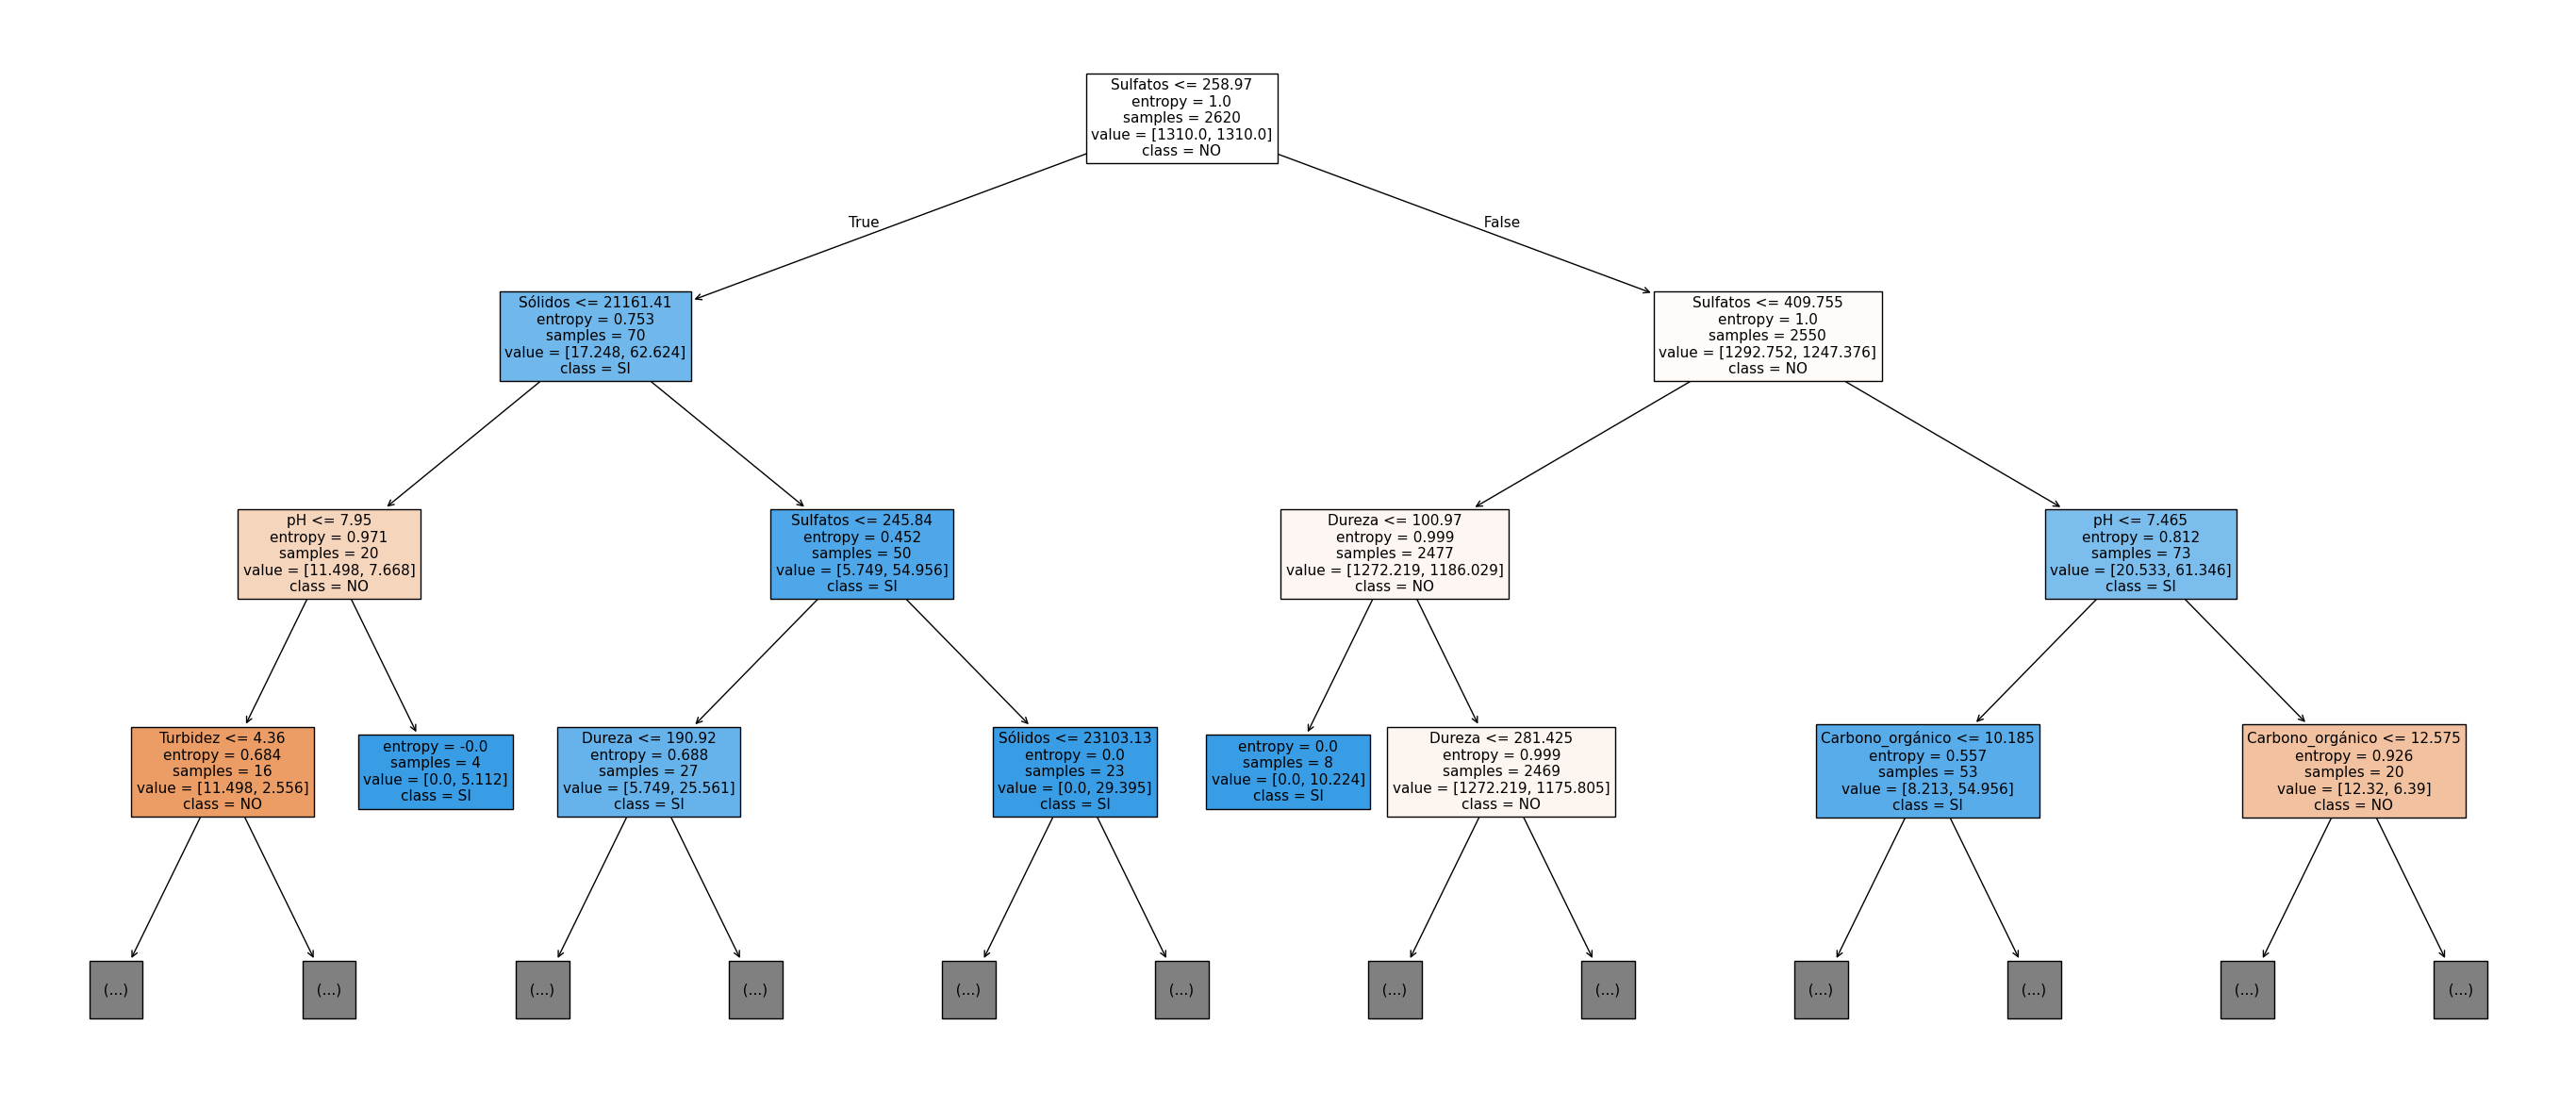

In [31]:
plt.figure(figsize=(35,15))
tree = plot_tree(mejor_modelo[1], feature_names=columnas_transformadas, class_names=['NO','SI'], filled=True, fontsize=11, max_depth =3)

###**Evaluación del mejor modelo**

In [32]:
x_test = test.drop(['Potabilidad'],axis=1)
y_test = pd.DataFrame(test['Potabilidad'])
y_test['Potabilidad'] = y_test['Potabilidad'].map({"NO": 0, "SI": 1})
y_test[['Potabilidad']].apply(pd.value_counts)


<ipython-input-32-a26074a05329>:4: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  y_test[['Potabilidad']].apply(pd.value_counts)


,Potabilidad
Potabilidad,
0,403
1,253


In [33]:
y_pred = mejor_modelo.predict(x_test)

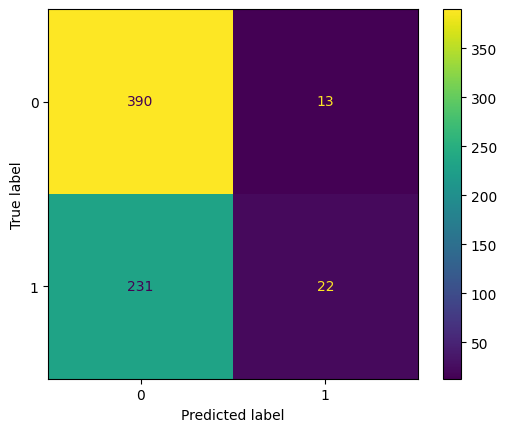

In [34]:
ConfusionMatrixDisplay.from_estimator(mejor_modelo, x_test, y_test)
plt.show()


In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.97      0.76       403
           1       0.63      0.09      0.15       253

    accuracy                           0.63       656
   macro avg       0.63      0.53      0.46       656
weighted avg       0.63      0.63      0.53       656



Se almacenan los resultados del modelo (exactitud, recall, precisión y F1) en la variable *report_modelo_1* para que las mismas puedan ser comparadas en la etapa de Análisis Comparativo.

In [36]:
report_modelo_1 = classification_report(y_test, y_pred, output_dict=True)

##**4. Construcción de un modelo utilizando el algoritmo K-vecinos mas cercanos**

### **Estandarización**

Se estandarizan las variables para que la escala no tenga influencia sobre el resultado de la clasificación.

In [37]:
x_train_m2 = x_train
y_train_m2 = y_train

In [38]:
pipeline_m2 = Pipeline([
    ('imputer', SimpleImputer()),             # Imputación numérica
    ('scaler', StandardScaler()),             # Estandarización
    ('knn', KNeighborsClassifier())           # Modelo KNN
])
pipeline_m2.set_output(transform="pandas")
pipeline_m2

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier())])

In [39]:
param_grid = {
    'imputer__strategy': ['mean', 'median'],     # Imputación: media o mediana
    'knn__n_neighbors': [1, 2, 3, 4, 5],         # Vecinos (k)
    'knn__weights': ['uniform', 'distance'],     # Pesos: uniforme o por distancia
    'knn__metric': ['euclidean', 'manhattan']    # Métricas de distancia
}

In [40]:
grid_m2 = GridSearchCV(
    estimator = pipeline_m2,
    param_grid=param_grid,
    cv=10,                  # Validación cruzada con 10 folds
    scoring='accuracy',     # Métrica de evaluación
    n_jobs=-1,              # Usar todos los núcleos disponibles
    verbose=1               # Nivel de detalle en el output
)

In [41]:
grid_m2.fit(x_train_m2, y_train_m2)

Fitting 10 folds for each of 40 candidates, totalling 400 fits


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'imputer__strategy': ['mean', 'median'],
                         'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': [1, 2, 3, 4, 5],
                         'knn__weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=1)

In [42]:
print("Mejores hiperparámetros:", grid_m2.best_params_)

Mejores hiperparámetros: {'imputer__strategy': 'median', 'knn__metric': 'euclidean', 'knn__n_neighbors': 2, 'knn__weights': 'uniform'}


In [43]:
best_k = grid_m2.best_params_['knn__n_neighbors']
print(f"El mejor número de vecinos (k) encontrado es: {best_k}")

El mejor número de vecinos (k) encontrado es: 2


In [44]:
best_strategy = grid_m2.best_params_['imputer__strategy']
best_weights = grid_m2.best_params_['knn__weights']
best_metric = grid_m2.best_params_['knn__metric']

# Crear el pipeline final con los mejores hiperparámetros
mejor_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy=best_strategy)),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k, weights=best_weights, metric=best_metric))
])

# Reentrenar el modelo con TODOS los datos
mejor_pipeline.fit(x_train_m2, y_train_m2)

print(f"Modelo reentrenado con k={best_k}, strategy={best_strategy}, weights={best_weights}, metric={best_metric}")


Modelo reentrenado con k=2, strategy=median, weights=uniform, metric=euclidean


###**Evaluación del modelo**

Se realiza la estandarización de los datos del conjunto de pruebas.

In [45]:
x_test_m2 = mejor_pipeline[0:2].transform(x_test)
y_test_m2 = y_test

Se realizan las predicciones utilizando el conjunto de pruebas para comparar con los valores de *y_test*:

In [46]:
y_pred_m2 = mejor_pipeline[2].predict(x_test_m2)

A continuación se obtiene la matriz de confusión:

In [47]:
confusion_matrix(y_test_m2, y_pred_m2)

array([[362,  41],
       [198,  55]])

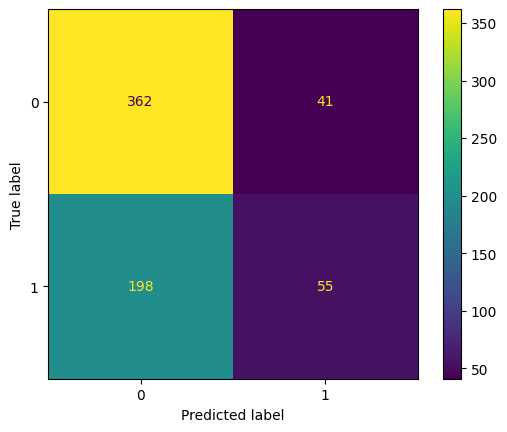

In [48]:
ConfusionMatrixDisplay.from_estimator(mejor_pipeline[2], x_test_m2, y_test_m2)
plt.show()

In [49]:
print(classification_report(y_test_m2, y_pred_m2))

              precision    recall  f1-score   support

           0       0.65      0.90      0.75       403
           1       0.57      0.22      0.32       253

    accuracy                           0.64       656
   macro avg       0.61      0.56      0.53       656
weighted avg       0.62      0.64      0.58       656



Se almacenan los resultados del modelo (exactitud, recall, precisión y F1) en la variable *report_modelo_2* para que las mismas puedan ser comparadas en la etapa de Análisis Comparativo.

In [50]:
report_modelo_2 = classification_report(y_test_m2, y_pred_m2, output_dict=True)

###**Disminución de Dimensionalidad**

Como complemento al desarrollo de los dos modelos, se realiza una primera aproximación desarrollando un modelo de KNN a través de la cual se disminuye la dimensionalidad del set de datos sin sacrificar datos en el proceso, utilizando para ello técnicas de PCA.

In [51]:
x_train_m3 = x_train
y_train_m3 = y_train
x_test_m3 = x_test
y_test_m3 = y_test

x_train_m3.columns = x_train_m3.columns.str.strip()
x_test_m3.columns = x_test_m3.columns.str.strip()


Se organizan grupos de variables integrandolas en 4 grupos, segun se describe abajo, disminuyendo la dimensión del set de datos de 9 variables a 4.

In [52]:
grupos = {
    'Propiedades_fisicas': ['Turbidez', 'Sólidos', 'Dureza'],
    'Quimica_organica': ['Carbono_orgánico', 'Trihalometanos'],
    'Quimica_inorganica': ['Sulfatos', 'Cloraminas'],
    'Generales': ['pH', 'Conductividad']
}

Desarrollo del pipeline bajo el nombre de pipeline_m3:

In [53]:
transformers = []
for grupo, variables in grupos.items():
    transformers.append((grupo, Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),  # Imputar valores faltantes con la media
        ('scaler', StandardScaler()),                 # Escalar las variables
        ('pca', PCA(n_components=min(len(variables), 2)))  # Reducir dimensiones (máx 2 componentes por grupo)
    ]), variables))

preprocessor = ColumnTransformer(transformers)

pipeline_m3 = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier(n_neighbors=5))  # KNN con k=5
])

pipeline_m3.fit(x_train_m3, y_train_m3)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('Propiedades_fisicas',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler()),
                                                                  ('pca',
                                                                   PCA(n_components=2))]),
                                                  ['Turbidez', 'Sólidos',
                                                   'Dureza']),
                                                 ('Quimica_organica',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler()),
                                                                  ('pca',
                                                                   PCA(n_components=2))]),
                                                  ['Carb...nico',
                                                   'Trihalometanos']),
                                                 ('Quimica_inorganica',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler()),
                                                                  ('pca',
                                                                   PCA(n_components=2))]),
                                                  ['Sulfatos', 'Cloraminas']),
                                                 ('Generales',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler()),
                                                                  ('pca',
                                                                   PCA(n_components=2))]),
                                                  ['pH', 'Conductividad'])])),
                ('knn', KNeighborsClassifier())])

In [54]:
param_grid_m3 = {
    'imputer__strategy': ['mean', 'median'],          # Imputación: media o mediana
    'scaler': [StandardScaler(), 'passthrough'],      # Escalar o no escalar
    'pca__n_components': [2, 3, 4, 5],                # Número de componentes principales
    'knn__n_neighbors': [1, 2, 3, 4, 5],              # Vecinos (k)
    'knn__weights': ['uniform', 'distance'],          # Pesos: uniforme o por distancia
    'knn__metric': ['euclidean', 'manhattan']         # Métricas de distancia
}

In [55]:
grid_search_m3 = GridSearchCV(pipeline_m3, param_grid_m3, cv=5, scoring='f1', n_jobs=-1, verbose=2)

Se obtienen la métricas de rendimiento usando los valores por defecto razonables para los hiperparámetros, funcionando como una primera aproximación. Es decir este modelo no esta optimizado con los mejores hiperparámetros debido al contexto computacional limitado, por lo tanto las optimizaciones mediante GridSearchCV no se completarán:  

In [56]:
y_pred_m3 = pipeline_m3.predict(x_test_m3)

In [57]:
print("Accuracy:", accuracy_score(y_test_m3, y_pred_m3))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_m3, y_pred_m3))
print("\nClassification Report:")
print(classification_report(y_test_m3, y_pred_m3))

Accuracy: 0.6234756097560976

Confusion Matrix:
[[309  94]
 [153 100]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.77      0.71       403
           1       0.52      0.40      0.45       253

    accuracy                           0.62       656
   macro avg       0.59      0.58      0.58       656
weighted avg       0.61      0.62      0.61       656



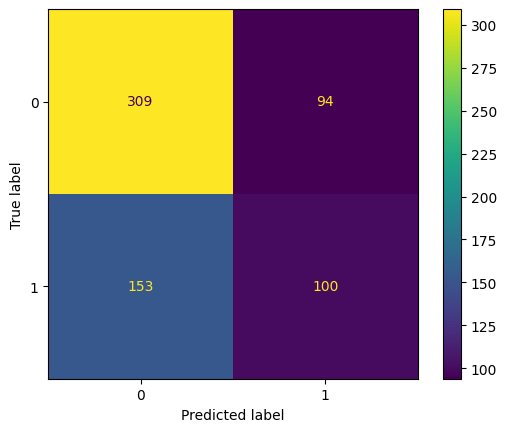

In [58]:
ConfusionMatrixDisplay.from_estimator(pipeline_m3, x_test_m3, y_test_m3)
plt.show()

Se almacenan los resultados de esta primera aproximación, la cual puede considerarse como una versión base del modelo KNN con PCA

In [59]:
report_modelo_3 = classification_report(y_test_m3, y_pred_m3, output_dict=True)

###**5. Tabla Comparativa - Rendimiento de los modelos obtenidos**

Generamos la tabla comparativa con los resultados de los tres modelos: Arbol de decisión, K-Vecinos y K-Vecinos con PCA.

In [60]:
datos_comparativos = {
    'Métrica': ['Precisión (Sí)', 'Recall (Sí)', 'F1-Score (Sí)',
                 'Precisión (No)', 'Recall (No)', 'F1-Score (No)',
                 'Exactitud'],
    'Arbol de Decisión': [
        report_modelo_1['1']['precision'],
        report_modelo_1['1']['recall'],
        report_modelo_1['1']['f1-score'],
        report_modelo_1['0']['precision'],
        report_modelo_1['0']['recall'],
        report_modelo_1['0']['f1-score'],
        report_modelo_1['accuracy']
    ],
    'K-vecinos': [
        report_modelo_2['1']['precision'],
        report_modelo_2['1']['recall'],
        report_modelo_2['1']['f1-score'],
        report_modelo_2['0']['precision'],
        report_modelo_2['0']['recall'],
        report_modelo_2['0']['f1-score'],
        report_modelo_2['accuracy']
    ],
    'KNN con PCA': [
        report_modelo_3['1']['precision'],
        report_modelo_3['1']['recall'],
        report_modelo_3['1']['f1-score'],
        report_modelo_3['0']['precision'],
        report_modelo_3['0']['recall'],
        report_modelo_3['0']['f1-score'],
        report_modelo_3['accuracy']
    ]
}

# Crear el DataFrame
tabla_comparativa = pd.DataFrame(datos_comparativos)
tabla_comparativa = tabla_comparativa.round(3)

# Función para resaltar máximos en verde, mínimos en rojo y dejar sin color los intermedios
def resaltar_max_min(val):
    max_val = tabla_comparativa.iloc[:, 1:].max(axis=1)
    min_val = tabla_comparativa.iloc[:, 1:].min(axis=1)
    if val in max_val.values:
        return 'background-color: lightgreen'
    elif val in min_val.values:
        return 'background-color: lightcoral'
    else:
        return ''

# Aplicar estilo
styled_table = tabla_comparativa.style.set_caption("Comparación de Métricas entre Modelos") \
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '16px'),
                                  ('font-weight', 'bold'),
                                  ('text-align', 'center')]}]) \
    .applymap(resaltar_max_min, subset=['Arbol de Decisión', 'K-vecinos', 'KNN con PCA']) \
    .set_properties(**{'border': '1px solid black', 'text-align': 'center'}) \
    .format(precision=3)

styled_table

<ipython-input-60-5dae935605aa>:55: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(resaltar_max_min, subset=['Arbol de Decisión', 'K-vecinos', 'KNN con PCA']) \


,Métrica,Arbol de Decisión,K-vecinos,KNN con PCA
0,Precisión (Sí),0.629,0.573,0.515
1,Recall (Sí),0.087,0.217,0.395
2,F1-Score (Sí),0.153,0.315,0.447
3,Precisión (No),0.628,0.646,0.669
4,Recall (No),0.968,0.898,0.767
5,F1-Score (No),0.762,0.752,0.714
6,Exactitud,0.628,0.636,0.623


### **6. Reglas para determinar cuando el agua no es potable**

Utilizando el modelo de árboles de decisión generado en el paso 3, se presentan las reglas que nos permiten determinar cuándo el agua no es apta para el consumo (Clase NO o Cero), tomando una profundidad de 3:

1. **Regla 1:** Si el nivel de Sulfatos es mayor que 258.97 (nivel 0), y mayor que 409.755 (nivel 1), y el pH es mayor que 7.465 (nivel 2) y el Carbono Orgánico sea menor o igual a 12.575 (nivel 3) existe una probabilidad de 61.6% que el agua no sea potable; es decir el modelo predice que el agua no es potable cuando el nivel de Sulfatos es mayor que 409.75 y su pH es mayor que 7.465 y el carbono orgánico es menor o igual a 12.575 con una probabilidad de 61.6%.
2. **Regla 2:** Si el nivel de Sulfatos es mayor que 258.97 (nivel 0), y menor o igual que 409.75 (nivel 1) y su Dureza es mayor que 100.97 (nivel 2) y la Dureza es menor o igual a 281.425 (nivel 3) existe una probabilidad de 51.52% de contar con agua no potable; por lo tanto, el modelo predice  con una probabilidad de 51.52% que el agua es no potable cuanto el nivel de Sulfatos se encuentre dentro del rango (258.97 , 409.755] y su Dureza dentro del rango (100.97, 281.425]. Considerar dentro de esta regla los límites los rangos indicados.
3. **Regla 3:** Si el nivel de Sulfatos es menor o igual que 258.97 (nivel 0), el nivel de Sólidos es menor o igual que 21,161.41 (nivel 1) y el pH es menor o igual a 7.95 (nivel 2) y la Turbidez sea menor o igual 4.36 (nivel 3) existe una probabilidad de 71.86% que el agua sea no potable; así que la regla quedaría de la siguiente manera el agua es no potable, con una probabilidad del 71.86% cuando el nivel de Sulfatos sea menor o igual a 258.97 y el nivel de Sólidos sea menor o igual a 21,161.41 y el pH sea menor o igual a 7.95 y la Turbidez sea menor o igual a 4.36.

### **7. Análisis de Resultados**

* *¿Qué puedes decir de los valores de las métricas recall y precisión para cada una de las clases en cada modelo? ¿Cuál de estás métricas consideras que es más importante con base en la descripción del problema?*

    El Recall o Sensibilidad de la clase NO: Medida que indica la capacidad del modelo para predecir si el agua es No Potable dada una cantidad de nuestras etiquetadas como NO. Los tres modelos ofrecen una medida alta de recall (superior al 75%), destacándose como el mejor el modelo de Árboles de Decisión con una medida de 0.96 (390 muestras correctamente identificadas / 403 muestras etiquetadas como NO). Considerando que el entorno es identificar muestras de agua para el consumo humano, esta medida es una de las mas importantes, ya que no sería aceptable que el modelo haga predicciones erroneas, prediciendo muestras de agua como potables cuando en realidad no lo son; a efectos de aplicaciones de salubridad publica requerimos un modelo con el mejor Recall Clase NO o 0 posible.

    El Recall o Sensibilidad de la clase SI: Esta medida indica la capacidad del modelo para predecir cuando el agua es Potable dada una cantidad de muestras identificadas como aptas para el consumo. Para este caso los modelos ofrecen métricas muy diferentes entre si, variando entre el 0.087 y el 0.395 correspondiente a KNN con PCA (100 muestras correctamente predichas / 253 muestras etiquetadas como SI). Un bajo desempeño en esta medida implicaría que el modelo predijera erróneamente muestras que son potables, identificandolas como que no lo son; a efectos de una planta de tratamiento de agua implicaría volver a procesar agua (que es potable) creyendo que no lo es. Tiene implicaciones de costos de procesamiento, pero no necesariamente implicaciones de salud pública. Un bajo Recall de esta clase sobrecargaría innecesariamente las plantas de tratamiento, si esta fuera su aplicación.

    La Precisión de la clase NO: Este indicador muestra la capacidad del modelo para predecir acertadamente la clase NO (agua no potable) sobre el total de predicciones realizadas. Los tres modelos ofrecen valores muy similares para esta medida alrededor de 0.6, destacándose con un mayor valor el modelo de KNN con PCA, con un valor de 0.669. Medida complementaria al Recall de la Clase SI; las implicaciones de una baja precisión para el NO no son tan relevantes para salud pública por las razones ya anotadas.

    La Precisión de la clase SI: Este indicador muestra la capacidad del modelo para predecir acertadamente la clase SI (agua potable) sobre el total de predicciones realizadas. La dispersión de esta medida entre los tres modelos es baja, variando entre 0.515 hasta 0.629 correspondiente al modelo de Árboles de Decisión (22 predicciones acertadas / 35 predicciones de la clase SI). Medida complementaria al Recall de la clase NO.

    Concluyendo:
    - Dado el objetivo de evitar riesgos sanitarios, el recall de la clase NO es la métrica crítica.
    - El Árbol de Decisión destaca en esta métrica (0.968), pero tiene un costo significativo en el recall de la clase SI.
    - KNN con PCA ofrece un balance más uniforme entre métricas, aunque con un recall de clase NO algo más bajo (0.767).

* *¿Consideras que el rendimiento de los modelos es adecuado? Si no es así, ¿Cómo podrían mejorarse los resultados?*

    Mi análisis gira en torno al objetivo de ofrecer un modelo con aplicaciones sobre la salud pública (consumo de agua potable) mas que sobre aplicaciones de otro tipo. Bajo la óptica indicada, y considerando todos los problemas ya anotados en el set de datos, se puede concluir que el modelo de Árbol de Decisión ofrece un rendimiento adecuado para la solución del problema, lo cual no significa que éste no pueda ser mejorado.

    Dentro de las mejoras que se pueden aplicar tenemos:
    - Aplicación de modelos mas complejos, tales como: Random Forest o Gradient Boosting o Redes Neuronales o como se mencionó previamente, terminar el modelo KNN con PCA con los mejores hiperparámetros. Estos modelos ofrecen opciones mas robustas y eliminan algunas limitaciones de los árboles de decision o de técnicas de KNN.
    - Utilizar técnicas de ajuste y optimización tales como ajuste de umbrales de decisión y balanceo de clases, por ejemplo utilización de submuestreo de la clase mayoritaria.
    - Optimización de hiperparámetros centrándose en maximizar el recall de la Clase NO.
    - Volver a lo básico, apoyarse en el juicio de expertos para evaluar en conjunto el set de datos, revisando el origen de los vacios, obtener mas muestras de la Clase SI (balancear el set), y/o aplicar el PCA bajo el criterio de expertos en la materia pueden ayudar a tener un modelo mas acertado.


* *¿Cuáles son las variables más significativas según el mejor modelo basado en árboles de decisión? Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.*
    
    Las variables mas importantes, según el modelo de Árboles de decisión son las siguientes:
    - Sulfatos
    - Dureza
    - pH

    A la luz de este conocimiento sobre cuales son las variables de mayor impacto, cobra aún mas relevancia la observación realizada en la respuesta anterior, sobre volver a lo básico; es decir dos de las tres variables mas importantes presentan importantes vacios en el set de datos; si bien estos vacios fueron imputados utilizando las técnicas correspondientes, en el contexto del problema se hace necesario revisar cómo se están obteniendo los datos. Identificar la causa raíz de los vacios presentados, dentro de las cuales podríamos encontrar: problemas con los instrumentos de medida, procesos de recolección de datos inadecuados, inconvenientes de integración entre diferentes aplicaciones, entre muchos otros; Para ello podemos utilizar alguna o algunas de las técnicas clásicas: analisis de Ishikawa, técnicas de los 5 por que?, Mapeos causales entre otros.

    Además, dado que variables como Trihalometanos, Cloraminas y Conductividad tienen importancia cero en el modelo, se recomienda:
    - Reevaluar si estas variables son esenciales para el monitoreo diario.
    - Reducir la complejidad del modelo eliminando variables irrelevantes para futuras iteraciones.

    Finalmente, propongo un enfoque iterativo donde, tras mejorar la recolección de datos, se reentrenen los modelos, enfocando recursos en las variables más críticas. Al mismo tiempo, establecer un sistema de alertas tempranas basado en los valores de Sulfatos, Dureza y pH puede fortalecer el proceso de toma de decisiones en las plantas de tratamiento (en caso que estos modelos se utilicen en este tipo de aplicaciones).
     
* *Si los dos modelos proporcionan resultados similares en cuanto a las métricas de rendimiento ¿Cuál seleccionarías tomando en cuenta el contexto del problema?*

Seleccionaría el modelo de Árboles de Decisión por las siguientes razones:

1. Prioridad a las métricas críticas para el contexto del problema:
Recall Clase NO (0.968): Es la métrica más relevante, ya que maximizar la identificación correcta de muestras no potables reduce el riesgo de agua peligrosa clasificada como potable.
Precisión Clase SI (0.629): Asegura que las muestras clasificadas como potables tengan una alta probabilidad de serlo realmente, disminuyendo reprocesos innecesarios en plantas de tratamiento.

2. Interpretabilidad del modelo:
El modelo de Árboles de Decisión permite una representación visual clara de las reglas de clasificación, facilitando la comprensión por parte de los expertos en tratamiento de agua. Esto promueve la confianza en las predicciones del modelo y la colaboración efectiva para mejorar iterativamente el modelo con base en el conocimiento experto.

3. Desempeño comparable en métricas generales:
Aunque el modelo de KNN con PCA tiene una ligera ventaja en exactitud (0.636 vs. 0.628), la diferencia es marginal. Las demás métricas clave (recall y precisión) favorecen al Árbol de Decisión.

4. Simplicidad y eficiencia computacional:
A diferencia de KNN con PCA, el modelo de Árboles de Decisión no requiere reducción de dimensionalidad ni cálculos intensivos durante la fase de predicción, lo que podría traducirse en:
Tiempo de inferencia más rápido (importante si el modelo debe implementarse en tiempo real).
Menor complejidad para actualizaciones futuras.


